In [1]:
import os
import pandas as pd
import numpy as np

ruta_base = "/root/Trabajo/Cedulas/Rotacion"  # Cambia esto por la ruta a tu carpeta raíz
data = []  # Lista para guardar (ruta, etiqueta)

for carpeta_actual, subcarpetas, archivos in os.walk(ruta_base):
    for archivo in archivos:
        if archivo.lower().endswith((".jpg", ".png")):
            ruta_completa = os.path.join(carpeta_actual, archivo)
            label = os.path.basename(carpeta_actual)
            data.append({"Path": ruta_completa, "Label": label, "Angle": 0.0})

# Crear el DataFrame
df = pd.DataFrame(data)
df["Label_decode"], uniques = pd.factorize(df["Label"])
df["Angle_rad"] = np.deg2rad(df["Angle"])
stratiffy = [i for i in uniques]
print(df.head())
# df.to_excel("df_oritation.xlsx")

                                                Path      Label  Angle  \
0  /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo    0.0   
1  /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo    0.0   
2  /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo    0.0   
3  /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo    0.0   
4  /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo    0.0   

   Label_decode  Angle_rad  
0             0        0.0  
1             0        0.0  
2             0        0.0  
3             0        0.0  
4             0        0.0  


In [2]:
import random


random.seed(42)

# Suponiendo que df ya existe
porcent=int(len(df)*0.7)
print(porcent)
df_rot = df.sample(n=porcent, random_state=42).copy()  # ⚠️ .copy() para evitar advertencias

# Asigna ángulos aleatorios entre 1° y 360°

df_rot["Angle"] = [random.uniform(1, 360) for _ in range(len(df_rot))]

# Convierte a radianes

df_rot["Angle_rad"] = np.deg2rad(df_rot["Angle"])
df.update(df_rot)

print(df.head())

223
                                                Path      Label      Angle  \
0  /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo  60.705689   
1  /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo   0.000000   
2  /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo  83.611189   
3  /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo  84.571928   
4  /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo   0.000000   

   Label_decode  Angle_rad  
0             0   1.059514  
1             0   0.000000  
2             0   1.459291  
3             0   1.476059  
4             0   0.000000  


In [3]:
import torch
from torchvision import models, transforms
from PIL import Image

# Cargar MobileNetV2 preentrenado
mobilenet = models.mobilenet_v2(weights="IMAGENET1K_V2")

# Eliminar la capa final (classifier) para quedarnos solo con las features
feature_extractor = mobilenet.features
feature_extractor.eval()  # modo evaluación

# Mover a GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor.to(device)

# Transformaciones estándar de ImageNet
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

def extract_features_from_image(image):
    
    image_tensor = preprocess(image).unsqueeze(0).to(device)  # [1, 3, 224, 224]
    
    with torch.no_grad():
        features = feature_extractor(image_tensor)  # [1, 1280, 7, 7]
        pooled = torch.nn.functional.adaptive_avg_pool2d(features, (1, 1))  # [1, 1280, 1, 1]
        vector = pooled.view(pooled.size(0), -1)  # [1, 1280]
    return vector.squeeze(0).cpu().numpy()  # numpy [1280,]



In [4]:
from PIL import Image

matrix = []
vectors = []
for i, row in df.iterrows():
    img = Image.open(row["Path"]).convert("RGB").rotate(row["Angle"])
    matrix.append(img)
    vectors.append(extract_features_from_image(img))

df["Matrix"] = matrix
df["Vectors"] = vectors

print(df.head)

<bound method NDFrame.head of                                                   Path      Label       Angle  \
0    /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo   60.705689   
1    /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo    0.000000   
2    /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo   83.611189   
3    /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo   84.571928   
4    /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo    0.000000   
..                                                 ...        ...         ...   
314  /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo  291.585534   
315  /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo  348.766662   
316  /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo   76.742841   
317  /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo    0.000000   
318  /root/Trabajo/Cedulas/Rotacion/No_angulo/Image...  No_angulo    0.000000  

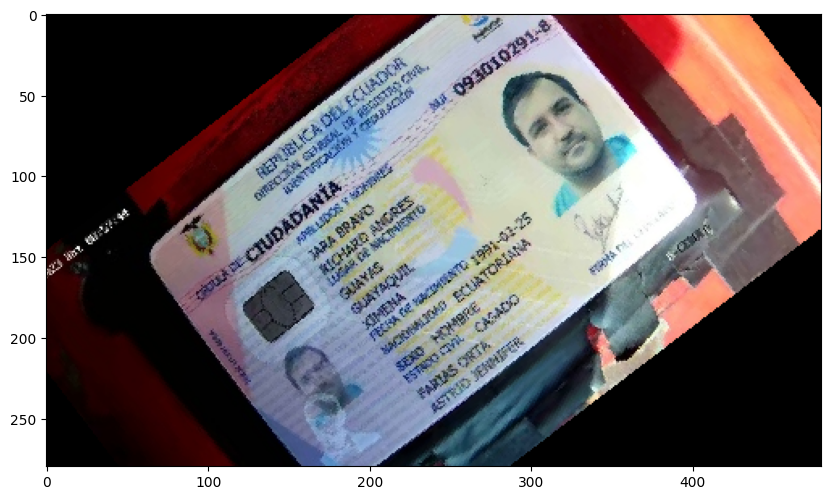

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.imshow(df["Matrix"][140])

In [6]:
from sklearn.model_selection import KFold,train_test_split

folder=KFold(n_splits=5)
X_train, X_test, y_train, y_test = train_test_split(
            df["Matrix"],
            df["Angle"],
            test_size=0.3,
            random_state=42,
            shuffle=True,
        )
kfolder = list(folder.split(X=X_train, y=y_train))
print(kfolder[0][1])

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44]


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math
import lightning as L
from PIL import Image

# --- Dataset adaptado ---
class DocumentOrientationDataset(Dataset):
    def __init__(self, annotations, transform=None):
        self.annotations = annotations
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        row = self.annotations.iloc[idx]
        image = row["Matrix"]
        angle_deg = row["Angle"]
        angle_rad = math.radians(angle_deg)
        target = np.array([math.sin(angle_rad), math.cos(angle_rad)], dtype=np.float32)
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(target)

# --- Transformaciones de imagen ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Modelo con Lightning ---
class OrientationModel(L.LightningModule):
    def __init__(self, lr=1e-4):
        super().__init__()
        self.lr=lr
        self.save_hyperparameters()
        base = models.mobilenet_v2(pretrained=True)
        num_features = base.classifier[1].in_features
        # Capas adicionales para mayor capacidad
        base.classifier = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(256, 256),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(256, 256),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(256, 256),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(256, 256),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(256, 2),
        )
        self.backbone = base
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        x = self.backbone(x)
        return nn.functional.normalize(x, dim=1)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y)
        error = self.angular_error(y_hat, y)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_angle_error", error, prog_bar=True)

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.lr,weight_decay=0.001)

    def angular_error(self, preds, targets):
        dot = torch.sum(preds * targets, dim=1).clamp(-1.0, 1.0)
        angles = torch.acos(dot)
        return torch.mean(angles * 180.0 / math.pi)

# --- Preparación de datos (ajustar según tus datos) ---
train_dataset = DocumentOrientationDataset(df.iloc[kfolder[0][0]], transform=transform)
val_dataset = DocumentOrientationDataset(df.iloc[kfolder[0][1]], transform=transform)
batch=128
train_loader = DataLoader(train_dataset, batch_size=batch, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch)

# --- Entrenamiento ---
model = OrientationModel(lr=1e-5)

early_stop_callback = L.pytorch.callbacks.EarlyStopping(
                monitor="val_loss",
                mode="min",
                patience=10,
            )
checkpoint_callback = L.pytorch.callbacks.ModelCheckpoint(
                save_top_k=2,
                save_last=True,
                monitor="val_loss",
                mode="min",
            )

callbacks = [early_stop_callback, checkpoint_callback]
trainer = L.Trainer(max_epochs=1000, accelerator="auto",callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name     | Type        | Params | Mode 
-------------------------------------------------
0 | backbone | MobileNetV2 | 2.8 M  | train
1 | loss_fn  | MSELoss     | 0      | train
-------------------------------------------------
2.8 M     Trainable params
0         Non-trainable params
2.8 M     Total params
11.262    Total estimated model params size (MB)
223       Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]